# find the DE genes between different clusters.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata

intersted_genes = ['Gpr101','Pdyn','Trhr','Tacr3','Shox2']
markergenes = ['Dbh', 'Th', 'Slc6a2']

import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
mesh_CD = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCD_ccf_v1_250102 2.obj")
mesh_CV = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCV_ccf_v1_250102 2.obj")
allmeshes = [mesh_LC,mesh_CD,mesh_CV]

In [2]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)

In [3]:
umap_random_state = 307
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state)
sc.tl.umap(adata_mer, random_state=210)

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


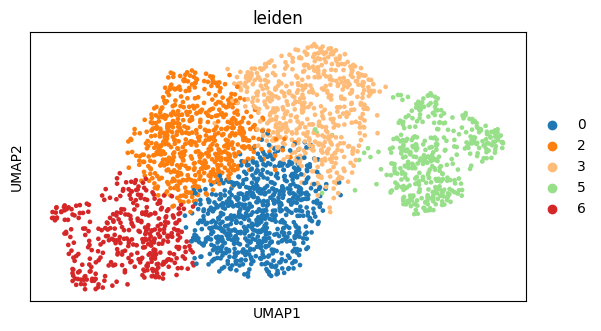

In [4]:
a = sc.pl.umap(adata_mer, color=['leiden'], show = False)
a.set_aspect('equal')

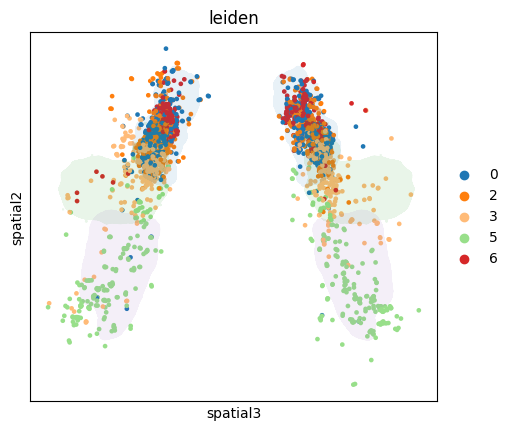

In [5]:
ax = sc.pl.embedding(adata_mer, basis = 'spatial', dimensions = (2,1), color = 'leiden', show = False)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
ax.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
ax.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')

In [6]:

sc.tl.rank_genes_groups(adata_mer, groupby='leiden', method='wilcoxon')

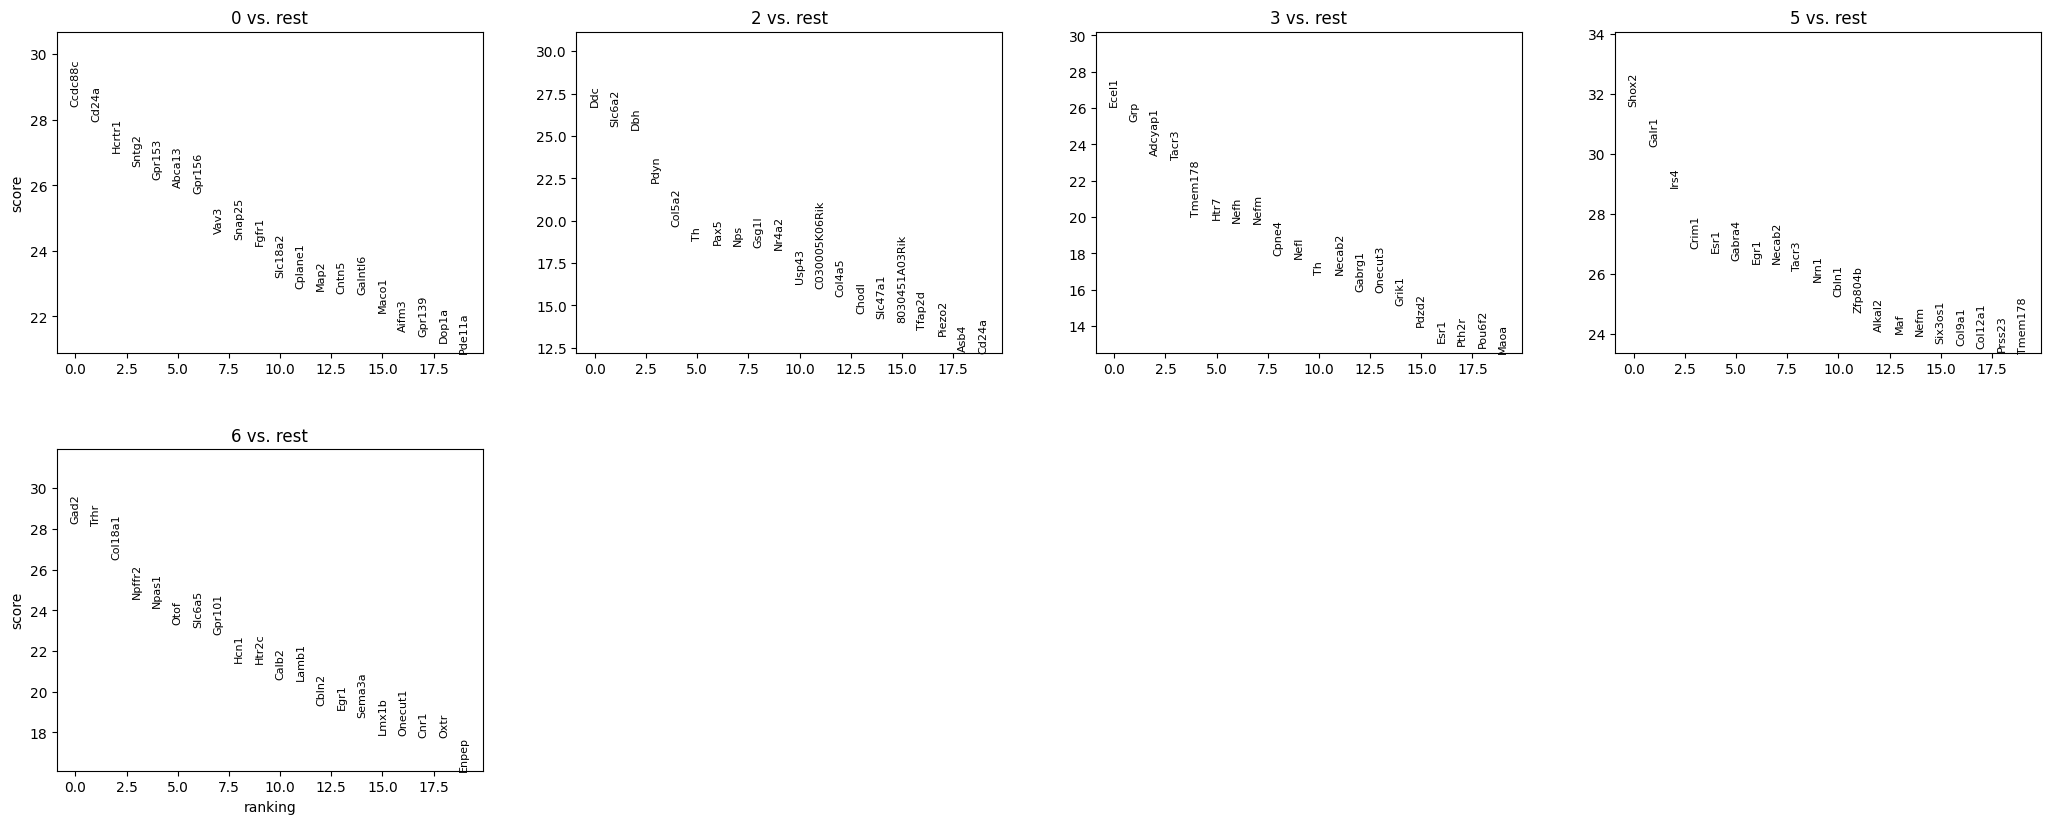

In [7]:
sc.pl.rank_genes_groups(adata_mer, n_genes=20, sharey=False, ncol=3)



/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 315 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


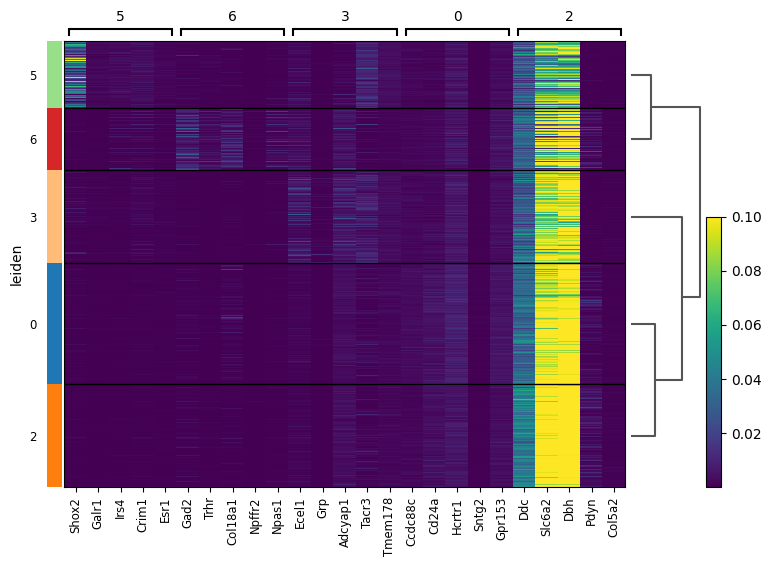

In [8]:
sc.pl.rank_genes_groups_heatmap(adata_mer, n_genes=5, key="rank_genes_groups", vmax = 0.1,
                                groupby="leiden", show_gene_labels=True)

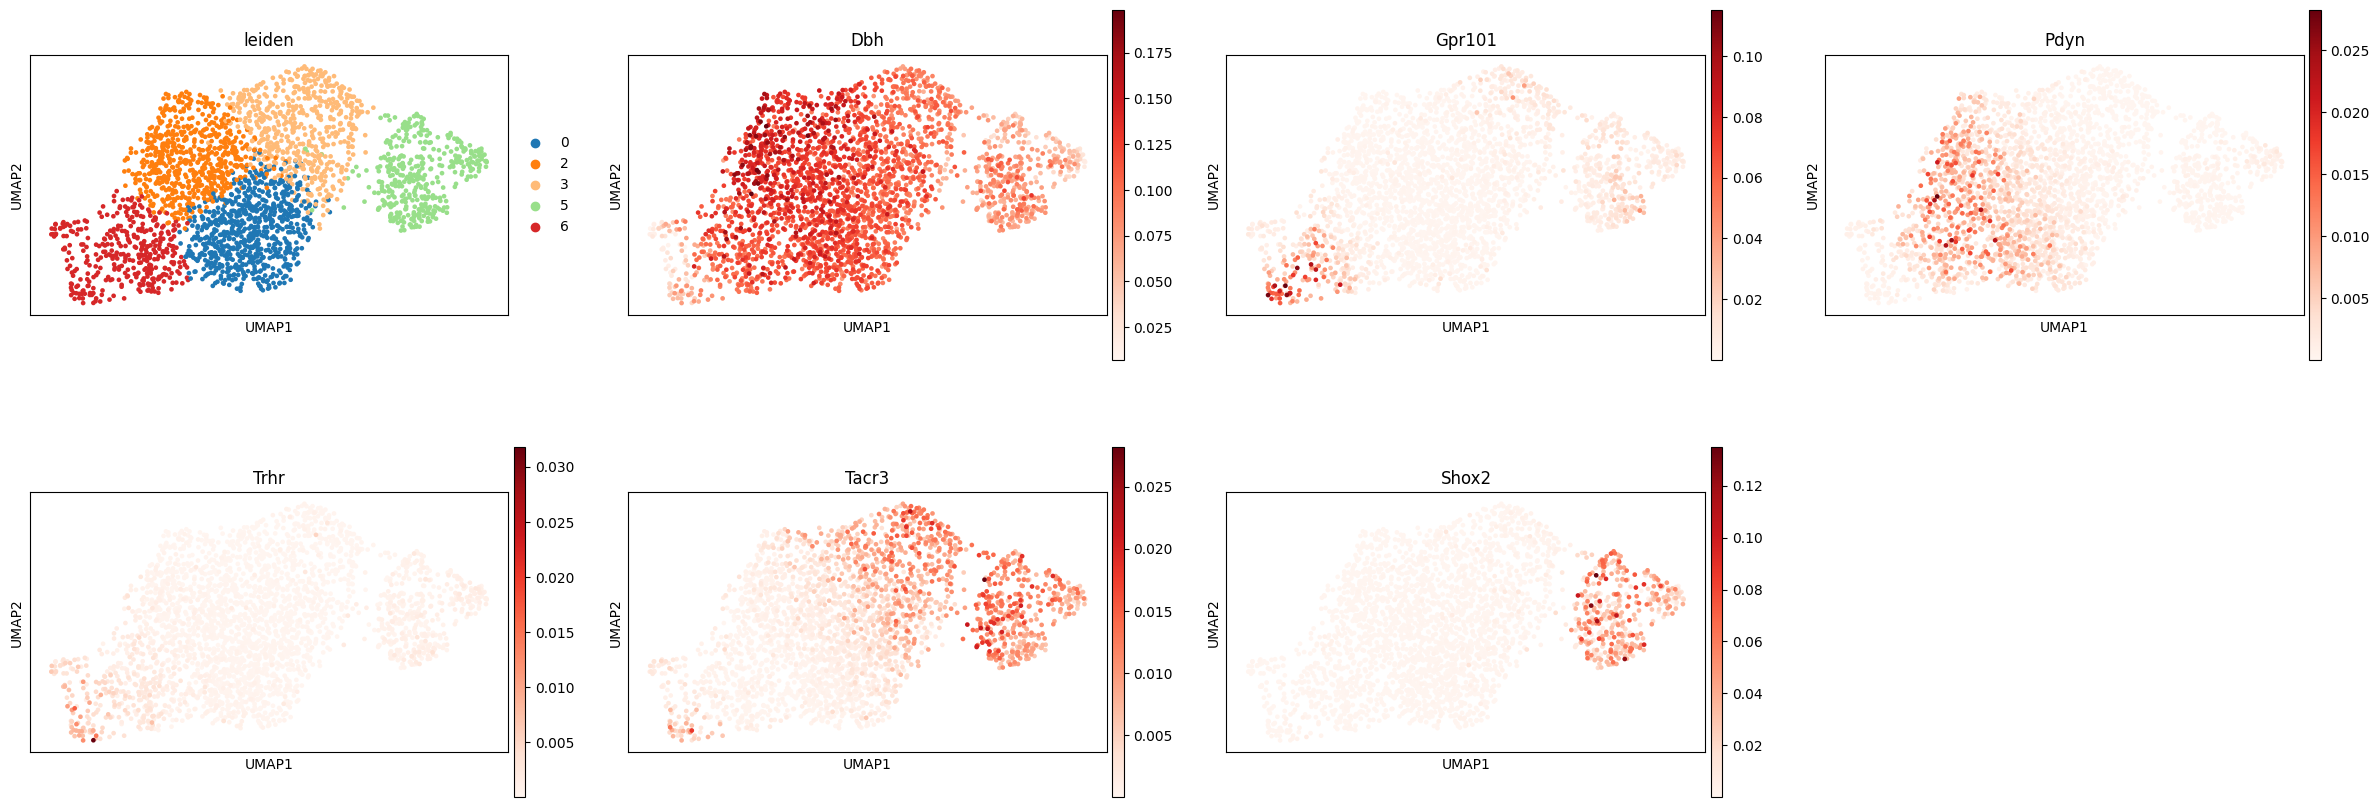

In [9]:
ax = sc.pl.umap(adata_mer, color=['leiden','Dbh'] + intersted_genes, 
                show = False, cmap = 'Reds')
for a in ax:
    a.set_aspect('equal')

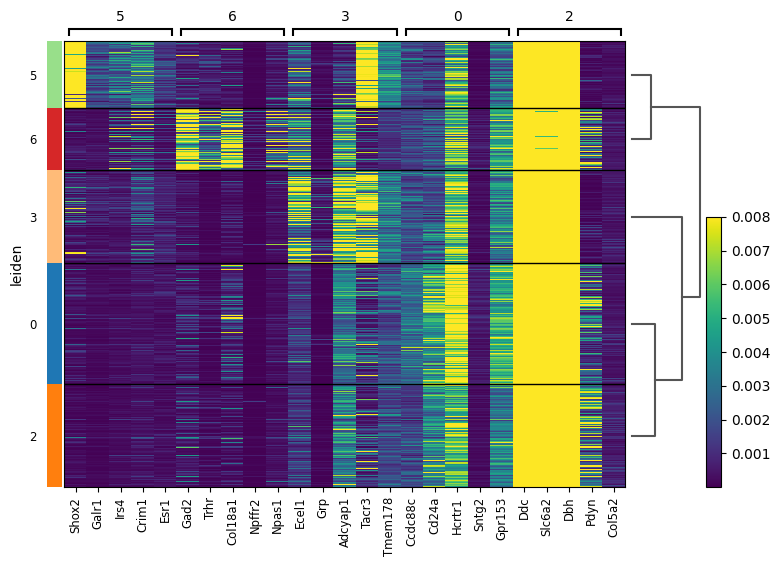

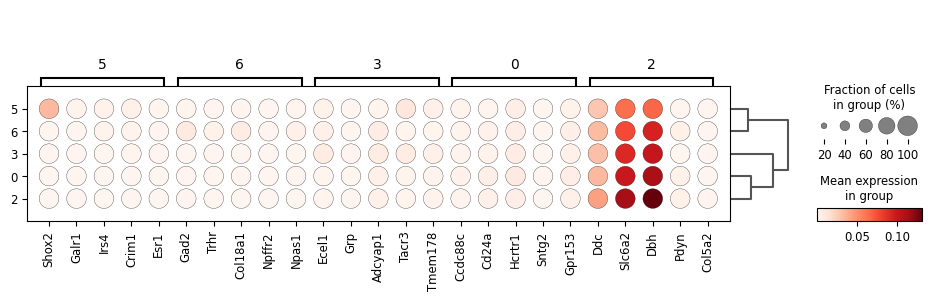

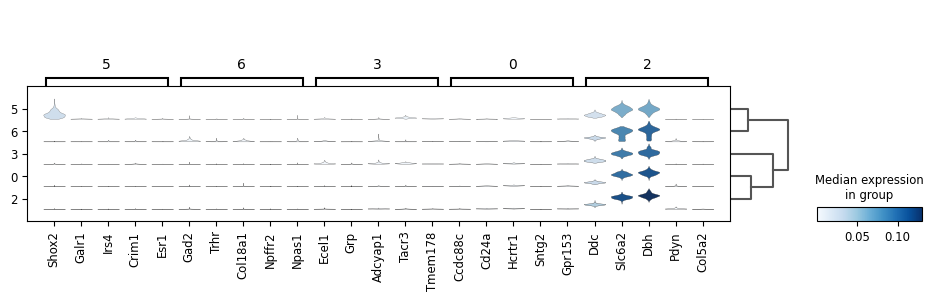

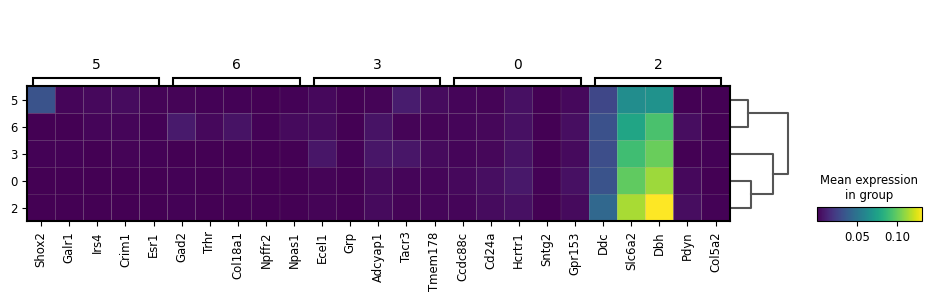

In [10]:
T = 5
sc.pl.rank_genes_groups_heatmap(adata_mer, n_genes=T, key="rank_genes_groups", 
                                groupby="leiden", show_gene_labels=True, vmax = 0.008)
sc.pl.rank_genes_groups_dotplot(adata_mer, n_genes=T, key="rank_genes_groups", 
                                groupby="leiden")
sc.pl.rank_genes_groups_stacked_violin(adata_mer, n_genes=T, key="rank_genes_groups", 
                                       groupby="leiden")
sc.pl.rank_genes_groups_matrixplot(adata_mer, n_genes=T, key="rank_genes_groups", groupby="leiden")

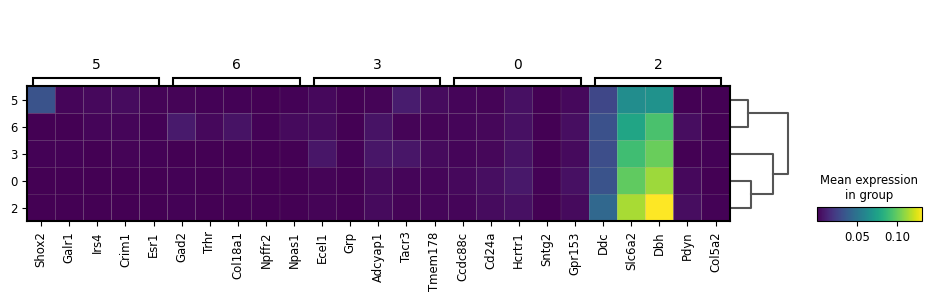

In [11]:
sc.pl.rank_genes_groups_matrixplot(adata_mer, n_genes=T, key="rank_genes_groups", groupby="leiden")

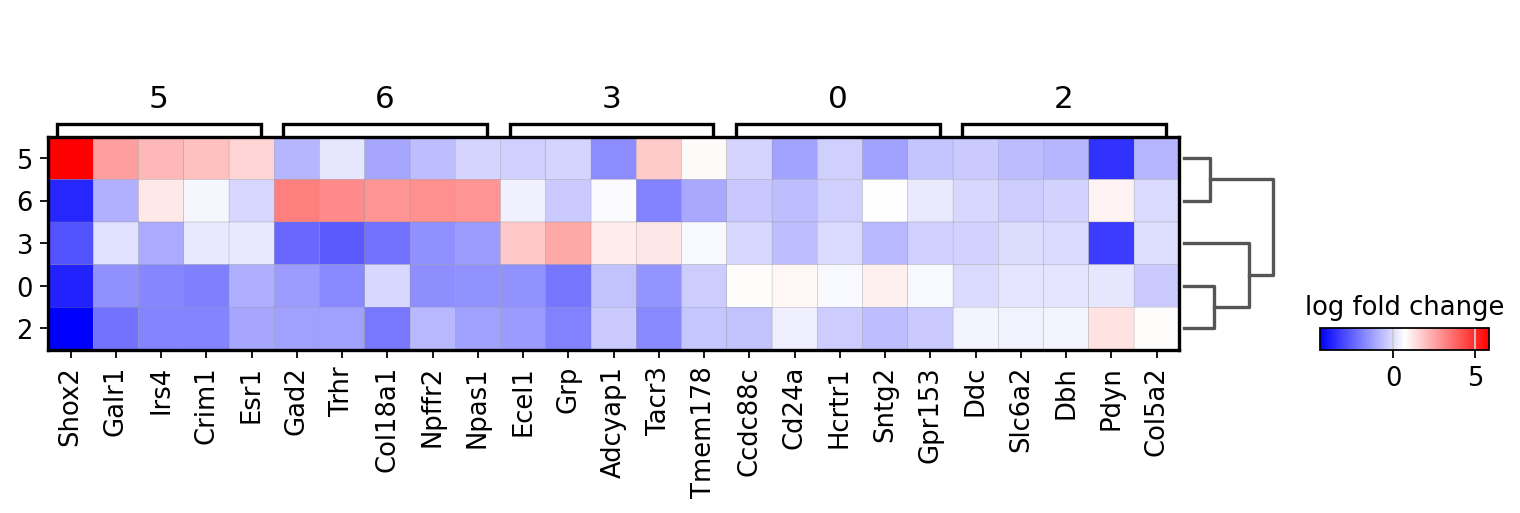

In [12]:
sc.settings.set_figure_params(dpi=80, figsize=(2, 2))
sc.pl.rank_genes_groups_matrixplot(adata_mer, 
                                   n_genes=T, cmap='bwr',
                                   key="rank_genes_groups",
                                   groupby="leiden", 
#                                    swap_axes=True, 
                                   values_to_plot="logfoldchanges",)


In [13]:
print(adata_mer.uns['rank_genes_groups']['names'])

[('Ccdc88c', 'Ddc', 'Ecel1', 'Shox2', 'Gad2')
 ('Cd24a', 'Slc6a2', 'Grp', 'Galr1', 'Trhr')
 ('Hcrtr1', 'Dbh', 'Adcyap1', 'Irs4', 'Col18a1')
 ('Sntg2', 'Pdyn', 'Tacr3', 'Crim1', 'Npffr2')
 ('Gpr153', 'Col5a2', 'Tmem178', 'Esr1', 'Npas1')
 ('Abca13', 'Th', 'Htr7', 'Gabra4', 'Otof')
 ('Gpr156', 'Pax5', 'Nefh', 'Egr1', 'Slc6a5')
 ('Vav3', 'Nps', 'Nefm', 'Necab2', 'Gpr101')
 ('Snap25', 'Gsg1l', 'Cpne4', 'Tacr3', 'Hcn1')
 ('Fgfr1', 'Nr4a2', 'Nefl', 'Nrn1', 'Htr2c')
 ('Slc18a2', 'Usp43', 'Th', 'Cbln1', 'Calb2')
 ('Cplane1', 'C030005K06Rik', 'Necab2', 'Zfp804b', 'Lamb1')
 ('Map2', 'Col4a5', 'Gabrg1', 'Alkal2', 'Cbln2')
 ('Cntn5', 'Chodl', 'Onecut3', 'Maf', 'Egr1')
 ('Galntl6', 'Slc47a1', 'Grik1', 'Nefm', 'Sema3a')
 ('Maco1', '8030451A03Rik', 'Pdzd2', 'Six3os1', 'Lmx1b')
 ('Aifm3', 'Tfap2d', 'Esr1', 'Col9a1', 'Onecut1')
 ('Gpr139', 'Piezo2', 'Pth2r', 'Col12a1', 'Cnr1')
 ('Dop1a', 'Asb4', 'Pou6f2', 'Prss23', 'Oxtr')
 ('Pde11a', 'Cd24a', 'Maoa', 'Tmem178', 'Enpep')
 ('Sulf1', 'Nts', 'Adarb2', 'Pd